In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import kagglehub
import os
warnings.filterwarnings('ignore')
path = kagglehub.dataset_download("yasserh/titanic-dataset")
file_to_load = os.path.join(path, 'Titanic-Dataset.csv')
df = pd.read_csv(file_to_load)

Using Colab cache for faster access to the 'titanic-dataset' dataset.


In [ ]:
df.shape

(891, 12)

In [ ]:
df.set_index('PassengerId', inplace = True)

In [ ]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,687


In [ ]:
df.Age.unique()

array([22.  , 38.  , 26.  , 35.  ,   nan, 54.  ,  2.  , 27.  , 14.  ,
        4.  , 58.  , 20.  , 39.  , 55.  , 31.  , 34.  , 15.  , 28.  ,
        8.  , 19.  , 40.  , 66.  , 42.  , 21.  , 18.  ,  3.  ,  7.  ,
       49.  , 29.  , 65.  , 28.5 ,  5.  , 11.  , 45.  , 17.  , 32.  ,
       16.  , 25.  ,  0.83, 30.  , 33.  , 23.  , 24.  , 46.  , 59.  ,
       71.  , 37.  , 47.  , 14.5 , 70.5 , 32.5 , 12.  ,  9.  , 36.5 ,
       51.  , 55.5 , 40.5 , 44.  ,  1.  , 61.  , 56.  , 50.  , 36.  ,
       45.5 , 20.5 , 62.  , 41.  , 52.  , 63.  , 23.5 ,  0.92, 43.  ,
       60.  , 10.  , 64.  , 13.  , 48.  ,  0.75, 53.  , 57.  , 80.  ,
       70.  , 24.5 ,  6.  ,  0.67, 30.5 ,  0.42, 34.5 , 74.  ])

In [ ]:
df.Embarked.unique()

array(['S', 'C', 'Q'], dtype=object)

In [ ]:

df.Embarked.fillna('S', inplace=True)
df.drop(columns=['Cabin'], inplace=True)
df['Age'].fillna(df['Age'].mean(), inplace=True)
df.isnull().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0
Embarked,0


In [ ]:
df['Sex'] = df['Sex'].map({'male' : 0, 'female' : 1})
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)
df['FamilySize'] = df['Parch'] + df['SibSp'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt','Col',
                                  'Don','Dr','Major','Rev','Sir','Jonkheer','Dona'], 'Rare')

df['Title'] = df['Title'].map({'Mr':0, 'Miss':1, 'Mrs':2, 'Master':3, 'Rare':4})
df.drop(columns=['Name', 'Ticket'], inplace=True)
df.drop(columns=['SibSp', 'Parch'], inplace=True)
df['Title'].fillna('4.0', inplace=True)

                                                  **VIZ**

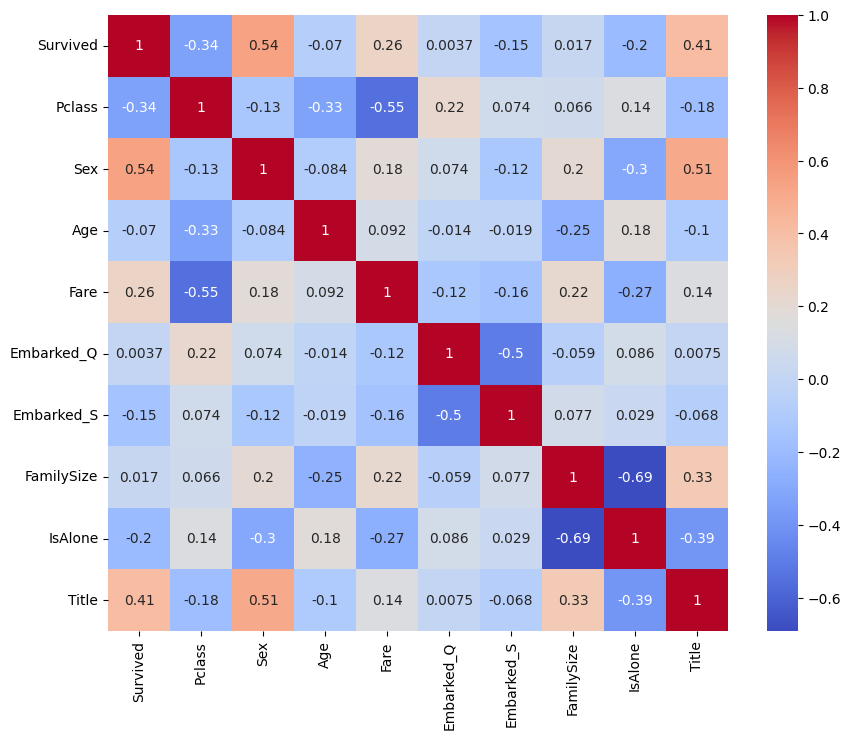

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

<Axes: xlabel='FamilySize', ylabel='Survived'>

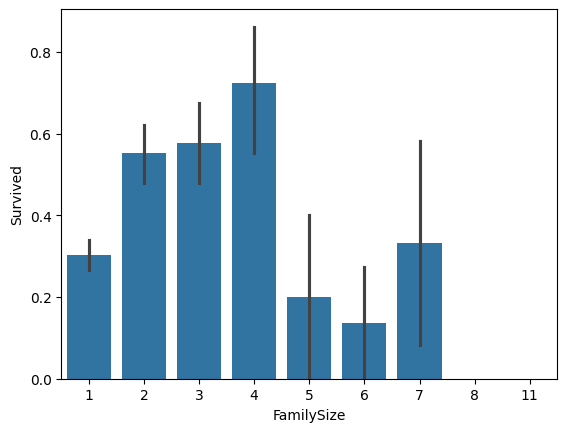

In [ ]:
sns.barplot(x='FamilySize', y='Survived', data=df)

<Axes: xlabel='Sex', ylabel='Survived'>

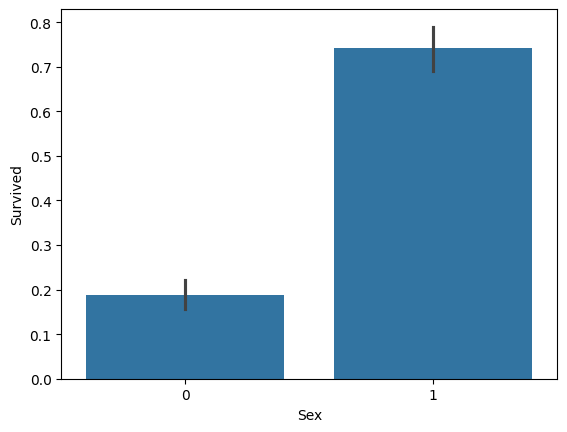

In [ ]:
sns.barplot(x='Sex', y='Survived', data=df)

<Axes: xlabel='Title', ylabel='Survived'>

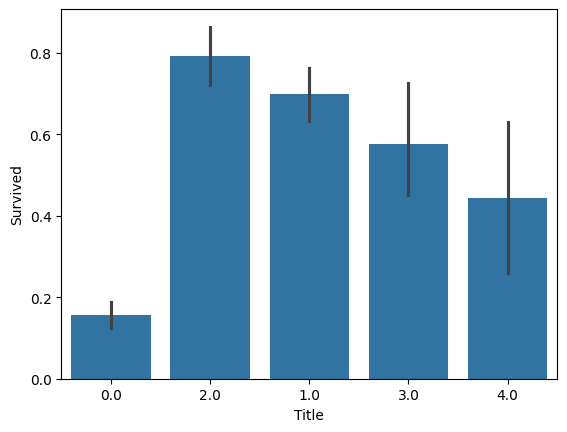

In [ ]:
sns.barplot(x='Title', y='Survived', data=df)

                                                   **Model**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.8379888268156425


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[97 11]
 [18 53]]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87       108
           1       0.83      0.75      0.79        71

    accuracy                           0.84       179
   macro avg       0.84      0.82      0.83       179
weighted avg       0.84      0.84      0.84       179



In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)
print(scores)
print(scores.mean())

[0.81564246 0.82022472 0.79213483 0.82022472 0.82022472]
0.8136902893729208


In [ ]:
train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)
print(train_acc, test_acc)

0.8174157303370787 0.8379888268156425
